In [4]:
# PHASE 2 — EXPLORATORY DATA ANALYSIS (EDA)
# Project: Cancel Culture — Customer Churn Analysis
# Dataset: Telco Customer Churn
# ============================================================
# CELL 1 — IMPORT LIBRARIES AND LOAD CLEAN DATA


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a clean visual style for all charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load your cleaned Telco data
df = pd.read_csv('/Users/hinahaq/Downloads/Final_Project/clean_data/Telco_Customer_Churn_cleaned.csv')

print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Churn rate: {df['Churn_Binary'].mean()*100:.1f}%")


Data loaded: 7032 rows, 21 columns
Churn rate: 26.6%


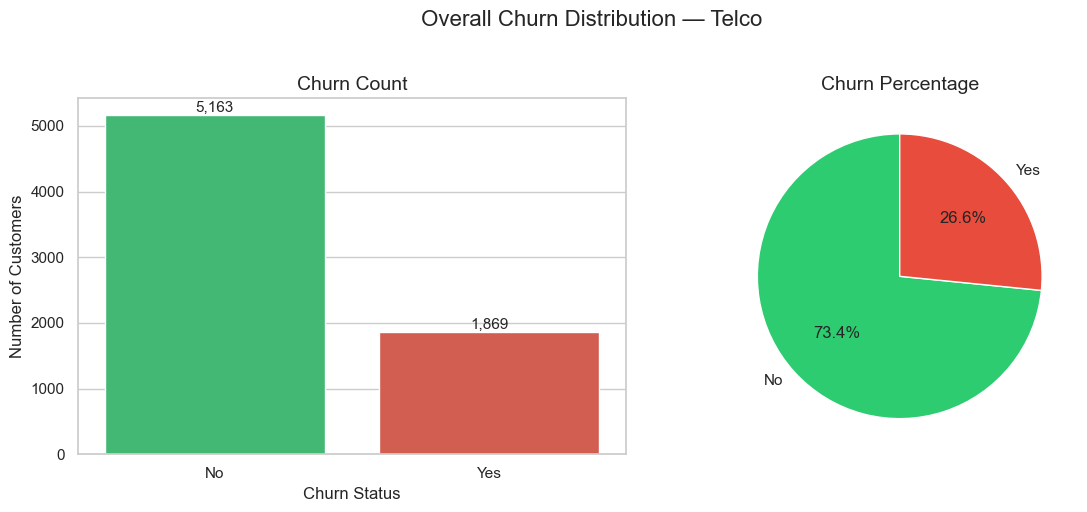

Cell 2 complete — Churn Distribution


In [5]:
# CELL 2 — CHURN DISTRIBUTION
# This cell shows how many customers churned vs stayed
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Count of churned vs stayed
sns.countplot(data=df, x='Churn', hue='Churn',
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
              legend=False, ax=axes[0])
axes[0].set_title('Churn Count', fontsize=14)
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')

# Add count labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Chart 2 — Percentage pie chart
churn_counts = df['Churn'].value_counts()
axes[1].pie(churn_counts, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14)

plt.suptitle('Overall Churn Distribution — Telco', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'eda_01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 2 complete — Churn Distribution")

**Out of 7,032 total customers:
5,163 stayed (73.4%)
1,869 left (26.6%)
So roughly 1 in 4 customers cancelled their subscription.**

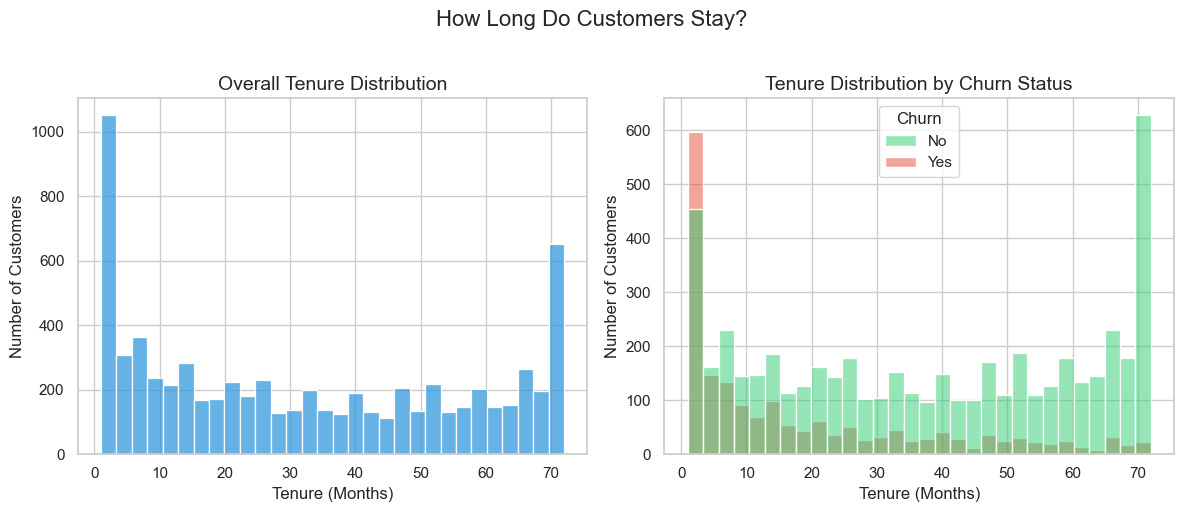

Cell 3 complete — Tenure Distribution


In [6]:
# CELL 3 — TENURE DISTRIBUTION
# This cell shows how long customers have been with the company
# We expect to see: new customers churn more than long-term ones
# Tenure = number of months as a customer
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Overall tenure distribution
sns.histplot(data=df, x='tenure', bins=30,
             color='#3498db', ax=axes[0])
axes[0].set_title('Overall Tenure Distribution', fontsize=14)
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Number of Customers')

# Chart 2 — Tenure split by churn status
sns.histplot(data=df, x='tenure', hue='Churn',
             bins=30, palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
             ax=axes[1])
axes[1].set_title('Tenure Distribution by Churn Status', fontsize=14)
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('How Long Do Customers Stay?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'eda_02_tenure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 3 complete — Tenure Distribution")



**0-12 months: 47.7% churn
13-24 months: 28.7% churn
25-48 months: 20.4% churn
49-72 months: 9.5% churn: loyal customer who spent more than 2 years are less likly to churn**





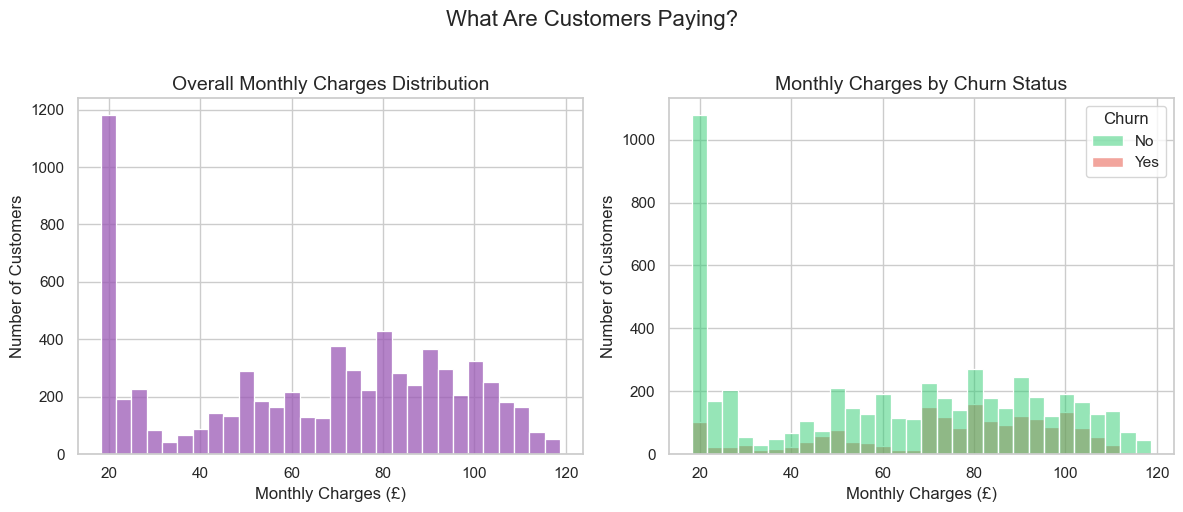

✅ Cell 4 complete — Monthly Charges Distribution


In [ ]:
# CELL 4 — MONTHLY CHARGES DISTRIBUTION
# This cell shows what customers are paying per month
# We expect to see: higher paying customers may churn more
# if they feel they are not getting value for money
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Overall monthly charges distribution
sns.histplot(data=df, x='MonthlyCharges', bins=30,
             color='#9b59b6', ax=axes[0])
axes[0].set_title('Overall Monthly Charges Distribution', fontsize=14)
axes[0].set_xlabel('Monthly Charges (£)')
axes[0].set_ylabel('Number of Customers')

# Chart 2 — Monthly charges split by churn
sns.histplot(data=df, x='MonthlyCharges', hue='Churn',
             bins=30, palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
             ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Status', fontsize=14)
axes[1].set_xlabel('Monthly Charges (£)')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('What Are Customers Paying?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'eda_03_monthly_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 4 complete — Monthly Charges Distribution")


**Monthly Charges and Churn:
The distribution of monthly charges shows that customers are spread across a wide range of prices, with a large number paying around the lower end of the scale. When we split the data by churn status, the churned customers appear more concentrated in the higher monthly charge ranges. This suggests that price may be an important factor in churn, especially for customers paying more for their service.  
In simple terms, customers who pay more each month seem more likely to leave, which could mean they are more sensitive to value or more likely to compare alternatives**

--- CHURN RATE BY CONTRACT TYPE ---
         Contract  Churn_Rate
0  Month-to-month   42.709677
1        One year   11.277174
2        Two year    2.848665


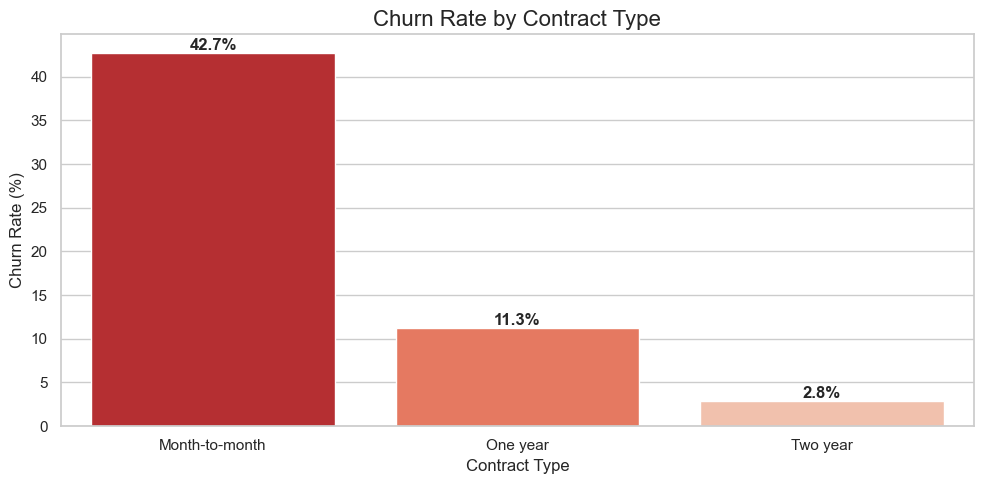

 Cell 5 complete — Churn by Contract Type


In [8]:
# CELL 5 — CHURN BY CONTRACT TYPE
# Contract type is typically the strongest predictor of churn
# Month-to-month customers have no commitment so they leave easily?
# ============================================================

# Calculate churn rate per contract type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
contract_churn = contract_churn.reset_index()
contract_churn.columns = ['Contract', 'Churn_Rate']
contract_churn = contract_churn.sort_values('Churn_Rate', ascending=False)

print("--- CHURN RATE BY CONTRACT TYPE ---")
print(contract_churn)

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=contract_churn, x='Contract', y='Churn_Rate',
                   hue='Contract', palette='Reds_r', legend=False)

# Add percentage labels on bars
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Churn Rate by Contract Type', fontsize=16)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig(project_path + 'eda_04_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Cell 5 complete — Churn by Contract Type")

**Churn Rate by Contract Type:
The difference between contract types is very strong. Customers on **month-to-month contracts** have by far the highest churn rate at **42.7%**, while customers on a **one-year contract** churn at only **11.3%** and those on a **two-year contract** churn at just **2.8%**.  
This is one of the clearest findings in the project: the more commitment a customer has, the less likely they are to leave.**

--- CHURN RATE BY TENURE GROUP ---
   Tenure_Group  Churn_Rate
0   0-12 months   47.678161
1  13-24 months   28.710938
2  25-48 months   20.388959
3  49-72 months    9.513176


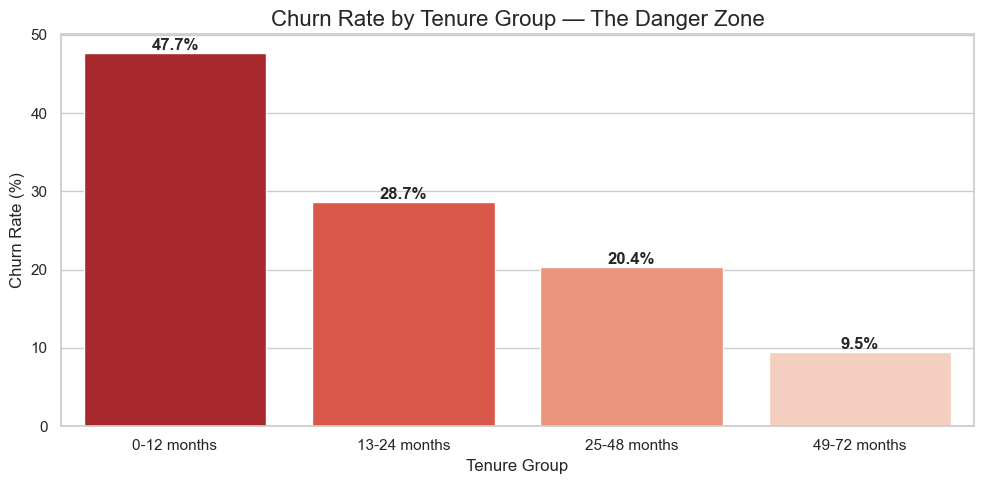

Cell 6 complete — Churn by Tenure Groups


In [9]:
# CELL 6 — CHURN BY TENURE GROUPS (THE DANGER ZONE)
# This cell finds the "danger zone" — which months are customers most likely to leave?
# We split tenure into groups: 0-12, 13-24, 25-48, 49-72 months
# ============================================================

# Create tenure groups
df['Tenure_Group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-12 months', '13-24 months',
                                     '25-48 months', '49-72 months'])

# Calculate churn rate per tenure group
tenure_churn = df.groupby('Tenure_Group', observed=True)['Churn_Binary'].mean() * 100
tenure_churn = tenure_churn.reset_index()
tenure_churn.columns = ['Tenure_Group', 'Churn_Rate']

print("--- CHURN RATE BY TENURE GROUP ---")
print(tenure_churn)

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=tenure_churn, x='Tenure_Group', y='Churn_Rate',
                   hue='Tenure_Group', palette='Reds_r', legend=False)

for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Churn Rate by Tenure Group — The Danger Zone', fontsize=16)
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig(project_path + 'eda_05_churn_by_tenure_group.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 6 complete — Churn by Tenure Groups")

**Churn Rate by Tenure Group:
The chart shows a very clear pattern: churn is highest among new customers and falls steadily as tenure increases. Customers in the first 0–12 months have the highest churn rate at **47.7%**, which suggests the first year is the most critical period for retention. After that, churn drops sharply to **28.7%** for 13–24 months, **20.4%** for 25–48 months, and only **9.5%** for customers who have stayed 49–72 months.  
This tells us that the longer a customer stays, the less likely they are to leave. The danger zone is clearly the early stage of the customer journey, so retention efforts should focus on the first year**

--- CHURN RATE BY INTERNET SERVICE ---
  InternetService  Churn_Rate
1     Fiber optic   41.892765
0             DSL   18.998344
2              No    7.434211


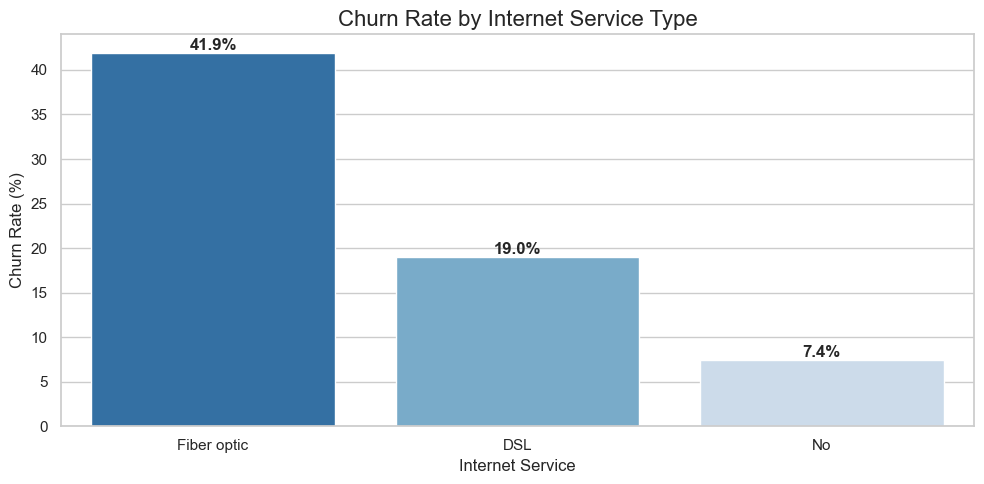

Cell 7 complete — Churn by Internet Service


In [10]:
# CELL 7 — CHURN BY INTERNET SERVICE
# This cell checks whether the type of internet service affects churn — fibre optic is faster but more expensive
# We expect: fibre optic customers may churn more
# ============================================================

internet_churn = df.groupby('InternetService')['Churn_Binary'].mean() * 100
internet_churn = internet_churn.reset_index()
internet_churn.columns = ['InternetService', 'Churn_Rate']
internet_churn = internet_churn.sort_values('Churn_Rate', ascending=False)

print("--- CHURN RATE BY INTERNET SERVICE ---")
print(internet_churn)

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=internet_churn, x='InternetService', y='Churn_Rate',
                   hue='InternetService', palette='Blues_r', legend=False)

for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Churn Rate by Internet Service Type', fontsize=16)
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig(project_path + 'eda_06_churn_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 7 complete — Churn by Internet Service")

**The Fibre Optic Paradox
Fibre optic: 41.9% churn
DSL: 19.0% churn
No internet: 7.4% churn
Fibre optic customers pay more AND leave more — suggests unmet expectations or quality issues with the premium service.**

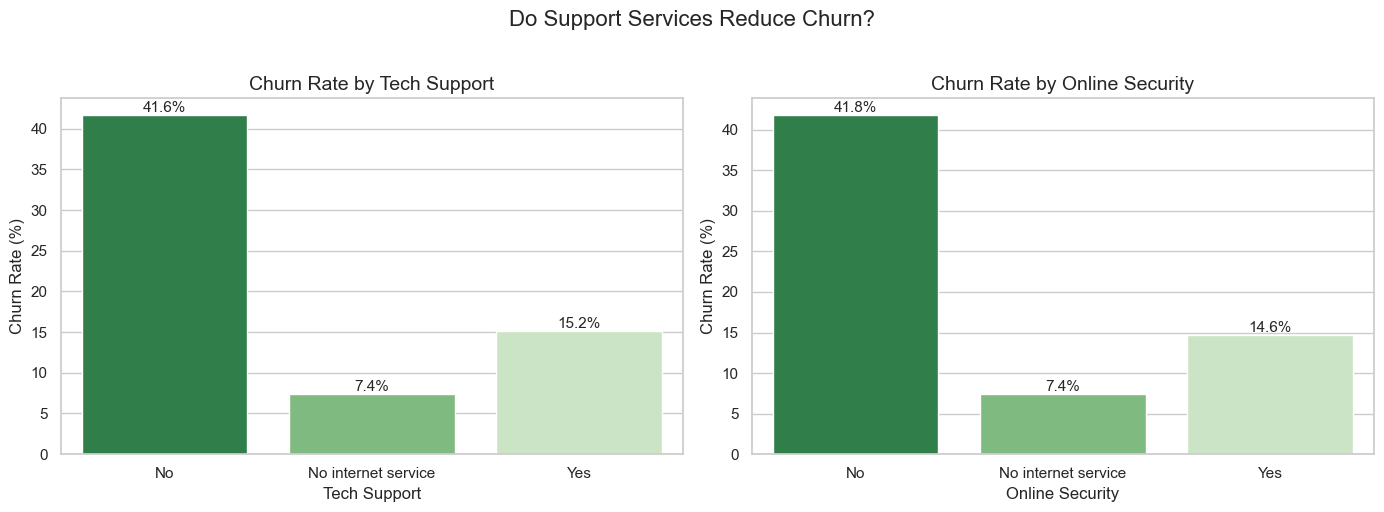

Cell 8 complete — Churn by Tech Support and Security


In [11]:
# CELL 8 — CHURN BY TECH SUPPORT AND ONLINE SECURITY
# This cell checks whether having support services reduces churn
# Logic: customers saty longer when help is avaiable 
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tech Support
tech_churn = df.groupby('TechSupport')['Churn_Binary'].mean() * 100
tech_churn = tech_churn.reset_index()
tech_churn.columns = ['TechSupport', 'Churn_Rate']

sns.barplot(data=tech_churn, x='TechSupport', y='Churn_Rate',
            hue='TechSupport', palette='Greens_r',
            legend=False, ax=axes[0])
axes[0].set_title('Churn Rate by Tech Support', fontsize=14)
axes[0].set_xlabel('Tech Support')
axes[0].set_ylabel('Churn Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Online Security
security_churn = df.groupby('OnlineSecurity')['Churn_Binary'].mean() * 100
security_churn = security_churn.reset_index()
security_churn.columns = ['OnlineSecurity', 'Churn_Rate']

sns.barplot(data=security_churn, x='OnlineSecurity', y='Churn_Rate',
            hue='OnlineSecurity', palette='Greens_r',
            legend=False, ax=axes[1])
axes[1].set_title('Churn Rate by Online Security', fontsize=14)
axes[1].set_xlabel('Online Security')
axes[1].set_ylabel('Churn Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.suptitle('Do Support Services Reduce Churn?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'eda_07_churn_by_support.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 8 complete — Churn by Tech Support and Security")

**Support Services Protect Customers:
No tech support: 41.6% churn
Has tech support: 15.2% churn
No online security: 41.8% churn
Has online security: 14.6% churn
Having support services cuts churn by almost two thirds. Customers who get help when things go wrong stay longer.**



--- CHURN RATE BY PAYMENT METHOD ---
               PaymentMethod  Churn_Rate
2           Electronic check   45.285412
3               Mailed check   19.201995
0  Bank transfer (automatic)   16.731518
1    Credit card (automatic)   15.253123


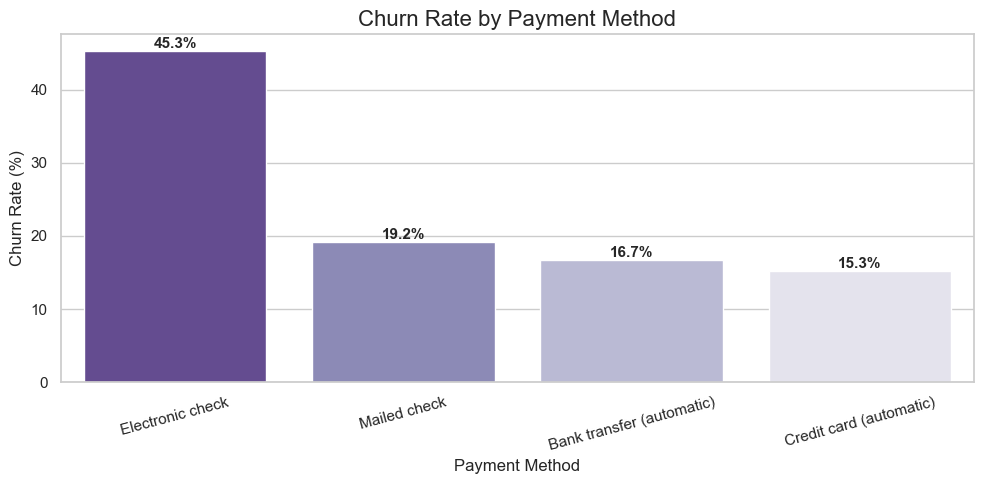

Cell 9 complete — Churn by Payment Method


In [20]:
# CELL 9 — CHURN BY PAYMENT METHOD
# This cell checks whether how customers pay affects churn
# Electronic check customers tend to churn more, they have less friction to cancel (no automatic payment)
# ============================================================

payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean() * 100
payment_churn = payment_churn.reset_index()
payment_churn.columns = ['PaymentMethod', 'Churn_Rate']
payment_churn = payment_churn.sort_values('Churn_Rate', ascending=False)

print("--- CHURN RATE BY PAYMENT METHOD ---")
print(payment_churn)

plt.figure(figsize=(10, 5))
bars = sns.barplot(data=payment_churn, x='PaymentMethod', y='Churn_Rate',
                   hue='PaymentMethod', palette='Purples_r', legend=False)

for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Churn Rate by Payment Method', fontsize=16)
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(project_path + 'eda_08_churn_by_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 9 complete — Churn by Payment Method")

**Churn by payment Method:
Electronic check: 45.3% churn
Mailed check: 19.2% churn
Bank transfer: 16.7% churn
Credit card: 15.3% churn
Electronic check customers churn at 3x the rate of automatic payment customers ,no automatic payment means no friction to cancel.**

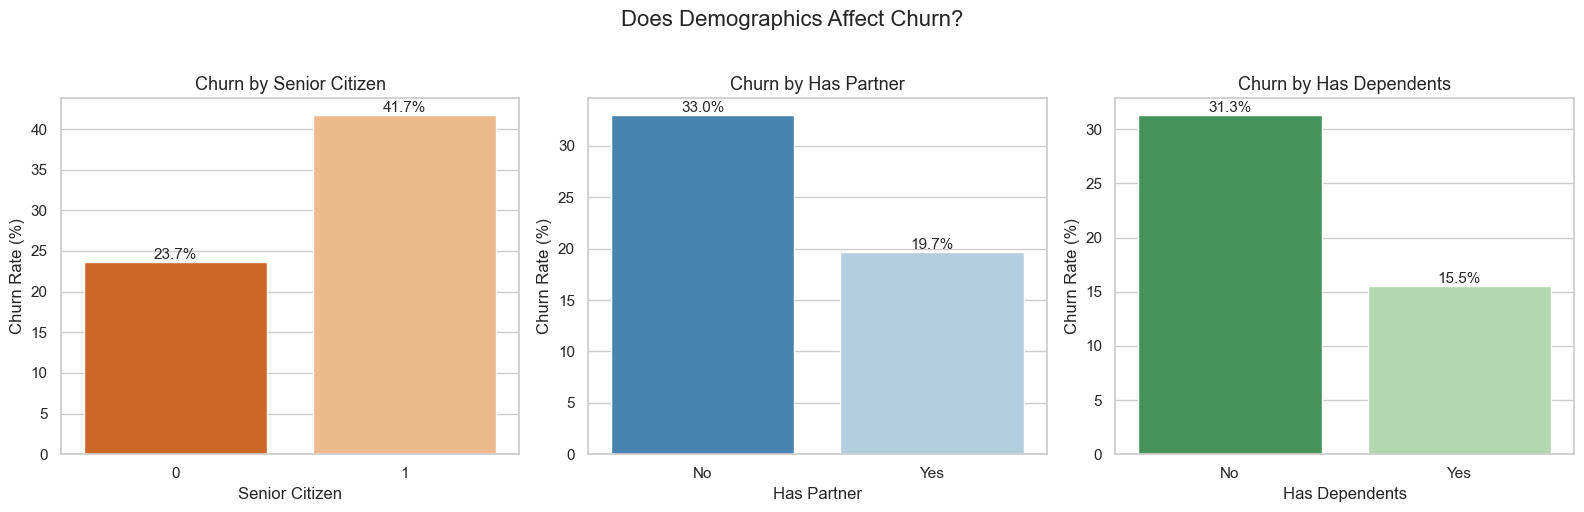

Cell 10 complete — Churn by Demographics


In [13]:
# CELL 10 — CHURN BY DEMOGRAPHICS
# This cell checks whether age (senior citizen) and
# family status (partner, dependents) affect churn
# Logic: customers with families may have more stability
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

demographic_vars = ['SeniorCitizen', 'Partner', 'Dependents']
titles = ['Senior Citizen', 'Has Partner', 'Has Dependents']
palettes = ['Oranges_r', 'Blues_r', 'Greens_r']

for i, (var, title, palette) in enumerate(zip(demographic_vars, titles, palettes)):
    demo_churn = df.groupby(var)['Churn_Binary'].mean() * 100
    demo_churn = demo_churn.reset_index()
    demo_churn.columns = [var, 'Churn_Rate']

    sns.barplot(data=demo_churn, x=var, y='Churn_Rate',
                hue=var, palette=palette,
                legend=False, ax=axes[i])
    axes[i].set_title(f'Churn by {title}', fontsize=13)
    axes[i].set_xlabel(title)
    axes[i].set_ylabel('Churn Rate (%)')
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='bottom', fontsize=11)

plt.suptitle('Does Demographics Affect Churn?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'eda_09_churn_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 10 complete — Churn by Demographics")

**Demographics Matter:
Senior citizens: 41.7% churn vs non-seniors 23.7%
No partner: 33.0% churn vs with partner 19.7%
No dependents: 31.7% churn vs with dependents 15.5%
Single, independent, senior customers are your highest risk group.**

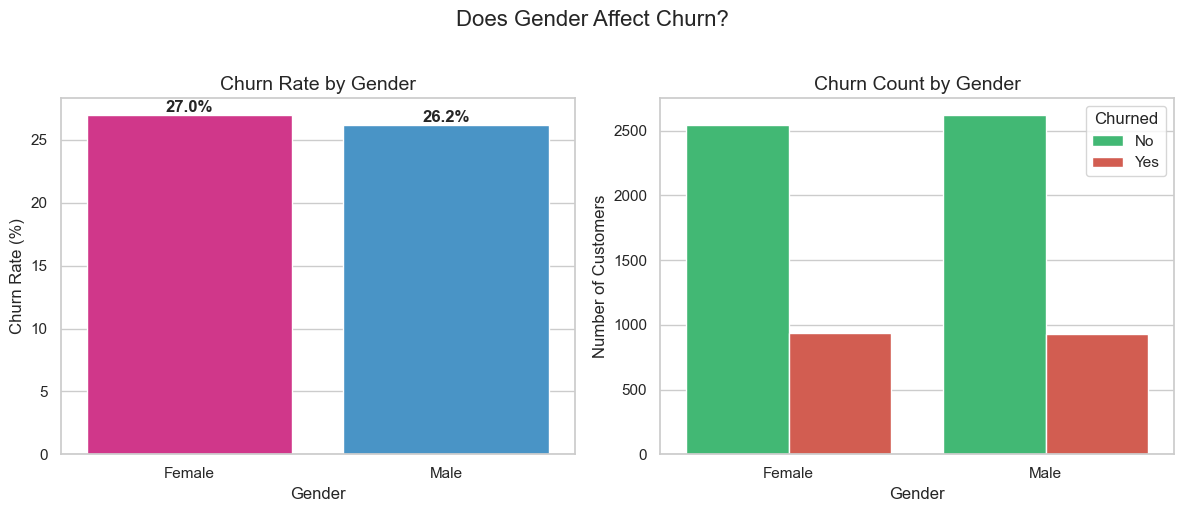

Cell 10A complete — Churn by Gender


In [18]:
# CELL 10A — CHURN BY GENDER
# This cell checks whether male or female customers churn more
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Churn rate by gender
gender_churn = df.groupby('gender')['Churn_Binary'].mean() * 100
gender_churn = gender_churn.reset_index()
gender_churn.columns = ['Gender', 'Churn_Rate']

bars = sns.barplot(data=gender_churn, x='Gender', y='Churn_Rate',
                   hue='Gender', palette={'Male': '#3498db', 'Female': '#e91e8c'},
                   legend=False, ax=axes[0])
axes[0].set_title('Churn Rate by Gender', fontsize=14)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Churn Rate (%)')
for p in bars.patches:
    bars.annotate(f'{p.get_height():.1f}%',
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='bottom', fontsize=12, fontweight='bold')

# Chart 2 — Count of male vs female customers overall
sns.countplot(data=df, x='gender', hue='Churn',
              palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
              ax=axes[1])
axes[1].set_title('Churn Count by Gender', fontsize=14)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(title='Churned')

plt.suptitle('Does Gender Affect Churn?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'eda_10a_churn_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 10A complete — Churn by Gender")

**not much diffrence**

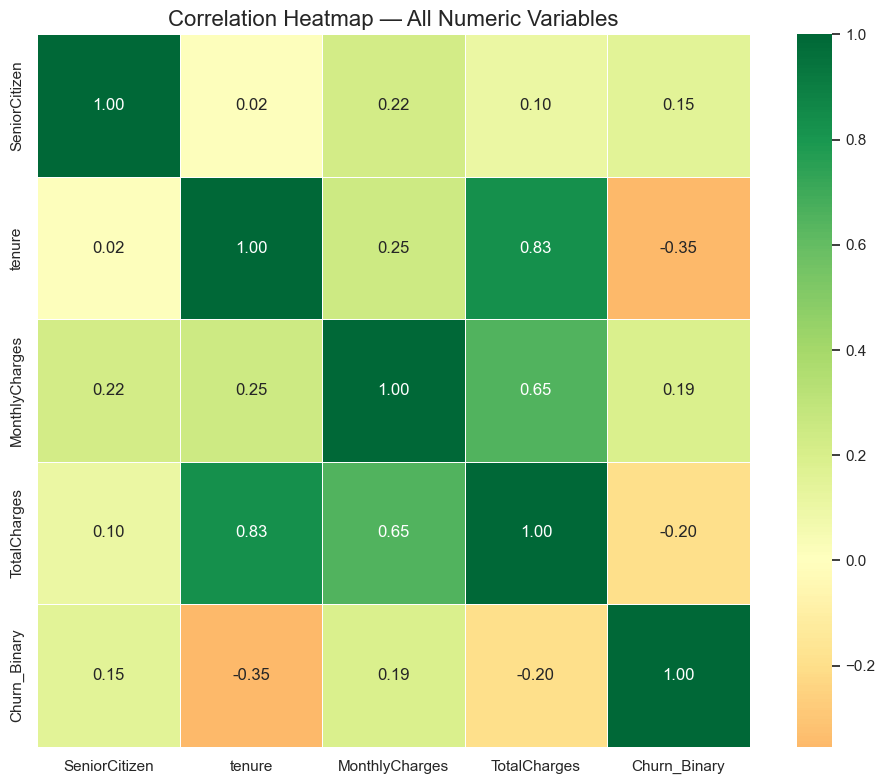

Cell 11 complete — Correlation Heatmap


In [19]:
# CELL 11 — CORRELATION HEATMAP
# This cell shows how all numeric variables relate to each other and to churn 
# darker colour = stronger relationship
# This helps identify which variables are most important
# ============================================================

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap — All Numeric Variables', fontsize=16)
plt.tight_layout()
plt.savefig(project_path + 'eda_10_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 11 complete — Correlation Heatmap")

**Correlation Heatmap Key Insights
Tenure vs Churn: -0.35 — longer customers churn less (confirms Finding 2)
Monthly charges vs Churn: +0.19 — higher charges = slightly more churn
Tenure vs TotalCharges: 0.83 — expected, longer = more total spend
Senior citizen vs Churn: 0.15 — weak but present**

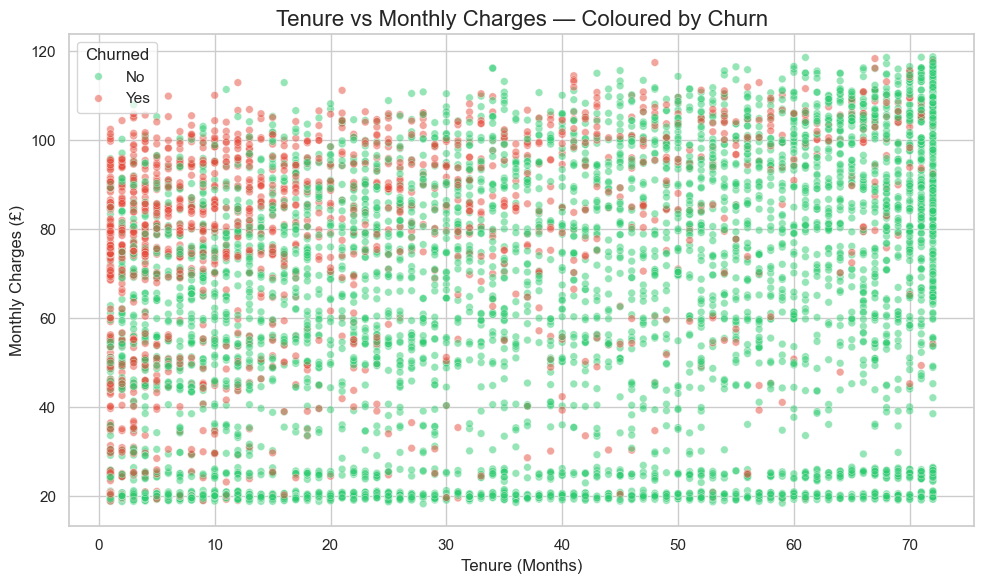

✅ Cell 12 complete — Tenure vs Monthly Charges


In [ ]:
# CELL 12 — TENURE VS MONTHLY CHARGES SCATTER PLOT
# This cell explores the relationship between how long a
# customer has stayed and what they pay
# We expect: longer customers may have negotiated better rates
# ============================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges',
                hue='Churn', palette={'No': '#2ecc71', 'Yes': '#e74c3c'},
                alpha=0.5, s=30)

plt.title('Tenure vs Monthly Charges — Coloured by Churn', fontsize=16)
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges (£)')
plt.legend(title='Churned')
plt.tight_layout()
plt.savefig(project_path + 'eda_11_tenure_vs_charges.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Cell 12 complete — Tenure vs Monthly Charges")



**Scatter Plot (Tenure vs Charges)
Red dots (churners) are heavily concentrated in bottom left — new customers paying low charges
Green dots dominate the right side — long-term customers who stayed
Confirms: early tenure is the danger zone regardless of price**

       REVENUE IMPACT OF CHURN
Total monthly revenue:     $455,661
Revenue from retained:     $316,530
Revenue LOST to churn:     $139,131
Revenue loss %:            30.5%
Churned customers:         1,869
Avg charge per churner:    $74.44


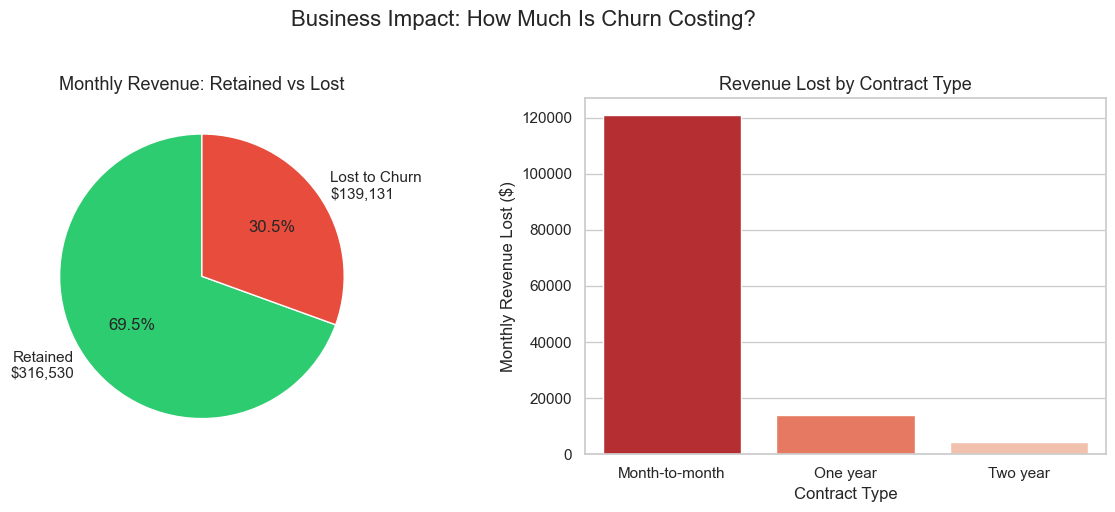

Cell 13 complete — Revenue Impact Analysis


In [16]:
# CELL 13 — REVENUE LOST TO CHURN
# This cell calculates the actual business impact of churn
# How much monthly revenue is the company losing?
# This is your most powerful business insight
# ============================================================

# Calculate revenue lost
total_monthly_revenue = df['MonthlyCharges'].sum()
churned_customers = df[df['Churn'] == 'Yes']
revenue_lost = churned_customers['MonthlyCharges'].sum()
revenue_retained = df[df['Churn'] == 'No']['MonthlyCharges'].sum()

print("=" * 45)
print("       REVENUE IMPACT OF CHURN")
print("=" * 45)
print(f"Total monthly revenue:     ${total_monthly_revenue:,.0f}")
print(f"Revenue from retained:     ${revenue_retained:,.0f}")
print(f"Revenue LOST to churn:     ${revenue_lost:,.0f}")
print(f"Revenue loss %:            {(revenue_lost/total_monthly_revenue)*100:.1f}%")
print(f"Churned customers:         {len(churned_customers):,}")
print(f"Avg charge per churner:    ${churned_customers['MonthlyCharges'].mean():.2f}")
print("=" * 45)

# Visualise revenue split
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 — Revenue pie
revenue_data = [revenue_retained, revenue_lost]
labels = [f'Retained\n${revenue_retained:,.0f}', f'Lost to Churn\n${revenue_lost:,.0f}']
axes[0].pie(revenue_data, labels=labels,
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Monthly Revenue: Retained vs Lost', fontsize=13)

# Chart 2 — Revenue lost by contract type
contract_revenue = df[df['Churn'] == 'Yes'].groupby('Contract')['MonthlyCharges'].sum()
contract_revenue = contract_revenue.reset_index()
contract_revenue.columns = ['Contract', 'Revenue_Lost']

sns.barplot(data=contract_revenue, x='Contract', y='Revenue_Lost',
            hue='Contract', palette='Reds_r', legend=False, ax=axes[1])
axes[1].set_title('Revenue Lost by Contract Type', fontsize=13)
axes[1].set_xlabel('Contract Type')
axes[1].set_ylabel('Monthly Revenue Lost ($)')

plt.suptitle('Business Impact: How Much Is Churn Costing?', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(project_path + 'eda_12_revenue_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cell 13 complete — Revenue Impact Analysis")


**The Revenue Story:
Monthly revenue lost to churn: $139,131
That is 30.5% of total revenue walking out the door every month
Average churner pays $74.44/month, these are not cheap customers**



In [17]:
# CELL 14 — TYPICAL CHURNER PROFILE
# This cell builds a summary of WHO the typical churner is
# This is your most actionable finding for business recommendations
# It answers: if you had to describe the customer most likely
# to leave, what would they look like?
# ============================================================

churned = df[df['Churn'] == 'Yes']
stayed = df[df['Churn'] == 'No']

print("=" * 55)
print("         TYPICAL CHURNER PROFILE SUMMARY")
print("=" * 55)
print(f"{'Metric':<30} {'Churned':>10} {'Stayed':>10}")
print("-" * 55)
print(f"{'Avg Tenure (months)':<30} {churned['tenure'].mean():>10.1f} {stayed['tenure'].mean():>10.1f}")
print(f"{'Avg Monthly Charges':<30} ${churned['MonthlyCharges'].mean():>9.2f} ${stayed['MonthlyCharges'].mean():>9.2f}")
print(f"{'Avg Total Charges':<30} ${churned['TotalCharges'].mean():>9.2f} ${stayed['TotalCharges'].mean():>9.2f}")
print(f"{'% Senior Citizens':<30} {churned['SeniorCitizen'].mean()*100:>9.1f}% {stayed['SeniorCitizen'].mean()*100:>9.1f}%")
print(f"{'% With Partner':<30} {(churned['Partner']=='Yes').mean()*100:>9.1f}% {(stayed['Partner']=='Yes').mean()*100:>9.1f}%")
print(f"{'% With Dependents':<30} {(churned['Dependents']=='Yes').mean()*100:>9.1f}% {(stayed['Dependents']=='Yes').mean()*100:>9.1f}%")
print(f"{'Most Common Contract':<30} {churned['Contract'].mode()[0]:>10} {stayed['Contract'].mode()[0]:>10}")
print(f"{'Most Common Payment':<30} {churned['PaymentMethod'].mode()[0]:>10} {stayed['PaymentMethod'].mode()[0]:>10}")
print(f"{'Most Common Internet':<30} {churned['InternetService'].mode()[0]:>10} {stayed['InternetService'].mode()[0]:>10}")
print("=" * 55)
print("\nCell 14 complete — Churner Profile Summary")


         TYPICAL CHURNER PROFILE SUMMARY
Metric                            Churned     Stayed
-------------------------------------------------------
Avg Tenure (months)                  18.0       37.7
Avg Monthly Charges            $    74.44 $    61.31
Avg Total Charges              $  1531.80 $  2555.34
% Senior Citizens                   25.5%      12.9%
% With Partner                      35.8%      52.8%
% With Dependents                   17.4%      34.3%
Most Common Contract           Month-to-month Month-to-month
Most Common Payment            Electronic check Mailed check
Most Common Internet           Fiber optic        DSL

Cell 14 complete — Churner Profile Summary


**The Typical Churner Profile:
A new customer (avg 18 months), paying $74/month, on a month-to-month contract, using fibre optic, paying by electronic check, no partner, no dependents, likely a senior citizen.**

